### RaschPy global MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 8 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Description(page 135 - RaschPy/RaschPy_manual.pdf):
Creates an object of the class MFRM from a pandas multiindex dataframe of polytomously scored data of items, rated by multiple raters which share the same maximum score for analysis. Return and object of class MFRM. Analyses are run using methods defined on the MFRM object, with results stored as attributes of the MFRM object.

self.dataframe (pandas multiindex dataframe): Dataframe of valid responses.
self.invalid responses (pandas multiindex dataframe): Dataframe of invalid responses (persons with no responses to any items, i.e. all missing data).

Import the modules and set the working directory (here called `my_working_directory`)to where you have saved the `mfrm_global_scores.csv` file - you will also save your output files here.

# reading the filepaths and converting to MFRM fromat

In [13]:
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# print((cwd.parent / "Analysis" / "mfrm_analysis.py").exists())
# print((cwd.parent / "config.py").exists())
# print("Project root:", PROJECT_ROOT)


In [14]:
from pathlib import Path
import sys
import RaschPy_aisi
from RaschPy_aisi import RaschPy as rp
import pandas as pd
import numpy as np
from itertools import combinations
from scipy import stats

import config
from config import DATA_DIR, OUTPUT_DIR, DIMENSIONS, COLORS, LLM_NAMES, ANNOTATOR_ID_MAP
from Analysis.mfrm_analysis import read_filepaths, creating_mfrm_ready_data, get_severity, plot_human_vs_llm_scatter_theta_new

In [78]:
# from mfrm_analysis import read_filepaths, creating_mfrm_ready_data

all_filepaths = read_filepaths(DATA_DIR)

filepath_gold = all_filepaths['gold']
filepath_GPT5= all_filepaths['GPT5_mono']
filepath_gpt5mini_modu= all_filepaths['gpt_5-mini_modu']
filepath_gpt5mini_mono= all_filepaths['gpt_5-mini_mono']
filepath_claude_modu= all_filepaths['claude_modu']
filepath_claude_mono= all_filepaths['claude_mono']
filepath_gemini_modu= all_filepaths['gemini_modu']
filepath_gemini_mono= all_filepaths['gemini_mono']
filepath_deepseek_modu= all_filepaths['deepseek_modu']
filepath_deepseek_mono= all_filepaths['deepseek_mono']

pd_dataframes, all_files, concat_df = creating_mfrm_ready_data(filepath_gold, filepath_GPT5, 
                                                               filepath_claude_mono, filepath_claude_modu, 
                                                               filepath_gpt5mini_mono, filepath_gpt5mini_modu, 
                                                               filepath_gemini_mono, filepath_gemini_modu, 
                                                               filepath_deepseek_mono,filepath_deepseek_modu,
                                                               output_dir=OUTPUT_DIR) 


Combined dataset:
Total rows in concatenated filtered df: 2855
Unique comments: 250
Unique raters: 591

checking for missing values

[Problem] WARNING: Missing values detected:
respect          151
insult           151
humiliate        151
status           158
dehumanize       151
violence         151
genocide         151
attack_defend    151
dtype: int64


In [129]:
pd_dataframes['gold'].shape #number of comment in the original gold dataset with duplicates

(605, 17)

In [8]:
concat_df['annotator_id'].value_counts().head(10)

annotator_id
gpt-5_mono         250
claude_mono        250
claude_modu        250
gpt-5-mini_mono    250
gpt-5-mini_modu    250
gemini_mono        250
gemini_modu        250
deepseek_mono      250
deepseek_modu      250
6177                 4
Name: count, dtype: int64

In [79]:
# base_dir_2 = Path(output_dir)
all_filepaths = read_filepaths(base_dir=OUTPUT_DIR)

def calibrate(filepath, label):
    """Helper to load and calibrate MFRM model."""
    print(f"  Calibrating {label}...")
    data, _ = rp.loadup_mfrm_single(filepath)
    model   = rp.MFRM(data)
    model.calibrate_global()
    return model

gold_data            = str(all_filepaths['gold'])
GPT5_mono_data       = str(all_filepaths['GPT5_mono'])
gpt5mini_mono_data   = str(all_filepaths['gpt_5-mini_mono'])
gpt5mini_modu_data   = str(all_filepaths['gpt_5-mini_modu'])
claude_mono_data     = str(all_filepaths['claude_mono'])
claude_modu_data     = str(all_filepaths['claude_modu'])
gemini_mono_data     = str(all_filepaths['gemini_mono'])
gemini_modu_data     = str(all_filepaths['gemini_modu'])
deepseek_mono_data   = str(all_filepaths['deepseek_mono']) 
deepseek_modu_data   = str(all_filepaths['deepseek_modu']) 

# Combined files
llm_human_mod_mono   = str(all_filepaths['llm_human_mod_mono']) # removed 4 here: question for team,
llm_only_mod_mono    = str(all_filepaths['llm_only_mod_mono'])
llm_only_mono        = str(all_filepaths['llm_only_mono'])
llm_only_modu        = str(all_filepaths['llm_only_modu'])
llm_mono_nogpt5      = str(all_filepaths['llm_mono_nogpt5'])

# =============================================================================
# CALIBRATE SEPARATE MODELS WITH MFRM
# =============================================================================
print("\nCalibrating separate models...")

# Individual annotator models
mfrm_humans        = calibrate(gold_data,           'Humans only')
mfrm_GPT5_mono     = calibrate(GPT5_mono_data,      'GPT5_mono')
mfrm_gpt5mini_mono = calibrate(gpt5mini_mono_data,  'GPT-5-mini mono')
mfrm_gpt5mini_modu = calibrate(gpt5mini_modu_data,  'GPT-5-mini modu')
mfrm_claude_mono   = calibrate(claude_mono_data,    'Claude mono')
mfrm_claude_modu   = calibrate(claude_modu_data,    'Claude modu')
mfrm_gemini_mono   = calibrate(gemini_mono_data,    'Gemini mono')
mfrm_gemini_modu   = calibrate(gemini_modu_data,    'Gemini modu')
mfrm_deepseek_mono = calibrate(deepseek_mono_data,  'DeepSeek mono')
mfrm_deepseek_modu = calibrate(deepseek_modu_data,  'DeepSeek modu')

# Combined models
mfrm_llms_only           = calibrate(llm_only_mod_mono,  'All LLMs mono+modu')
mfrm_llms_mono           = calibrate(llm_only_mono,      'All LLMs mono only')
mfrm_llms_mono_nogpt5    = calibrate(llm_mono_nogpt5,    'LLMs mono-no GPT5')
mfrm_llms_modu           = calibrate(llm_only_modu,      'All LLMs modu only')
mfrm_all                 = calibrate(llm_human_mod_mono, 'All raters combined')
# mfrm_all_unfil           = calibrate(llm_)

print("\n✓ All models calibrated")
# =============================================================================
# EXTRACT ITEM DIFFICULTIES and determing strictest and most lenient LLMs
# =============================================================================

comparison = pd.DataFrame({
    'humans'           : mfrm_humans.diffs,
    'GPT5_mono'        : mfrm_GPT5_mono.diffs,
    'gpt5mini_mono'    : mfrm_gpt5mini_mono.diffs,
    'gpt5mini_modu'    : mfrm_gpt5mini_modu.diffs,
    'claude_mono'      : mfrm_claude_mono.diffs,
    'claude_modu'      : mfrm_claude_modu.diffs,
    'gemini_mono'      : mfrm_gemini_mono.diffs,
    'gemini_modu'      : mfrm_gemini_modu.diffs,
    'deepseek_mono'    : mfrm_deepseek_mono.diffs,
    'deepseek_modu'    : mfrm_deepseek_modu.diffs,
    'llm_only_mono'    : mfrm_llms_mono.diffs,
    'llm_mono_nogpt5'  : mfrm_llms_mono_nogpt5.diffs,
    'llm_only_modu'    : mfrm_llms_modu.diffs,
    'llm_only_mod_mono': mfrm_llms_only.diffs,
    'llm_human_all'    : mfrm_all.diffs,
    # 'llm_huma_all_unfil' : mfrm_all_unfil.diffs,
})

# LLM_COLS =LLM_NAMES[:-2]                    

# Human vs LLM mono difference
comparison['Hu_vs_LLM_mono'] = comparison['humans'] - comparison['llm_only_mono']
comparison['interpretation_hu_llm(mono)'] = comparison['Hu_vs_LLM_mono'].apply(
    lambda x: 'LLM Stricter (Finds Harder)' if x < 0 else 'LLM Lenient (Finds Easier)'
)

# Human vs LLM mono excluding GPT5 difference
comparison['Hu_vs_LLM_mono_nogpt5'] = comparison['humans'] - comparison['llm_mono_nogpt5']
comparison['interpretation_hu_llm(mono_nogppt5)'] = comparison['Hu_vs_LLM_mono_nogpt5'].apply(
    lambda x: 'LLM Stricter (Finds Harder)' if x < 0 else 'LLM Lenient (Finds Easier)'
)

# Human vs LLM modu difference
comparison['Hu_vs_LLM_modu'] = comparison['humans'] - comparison['llm_only_modu']
comparison['interpretation_hu_llm(modu)'] = comparison['Hu_vs_LLM_modu'].apply(
    lambda x: 'LLM Stricter (Finds Harder)' if x < 0 else 'LLM Lenient (Finds Easier)'
)

LLM_COLS = [col for col in comparison.columns if col in LLM_NAMES] #llm names only contains original llms names

# Rankings
for col in ['humans', 'llm_only_mono', 'llm_only_mono','llm_only_mod_mono', ]:
    comparison[f'{col}_rank'] = comparison[col].rank()

# =============================================================================
# ITEM DIFFICULTY COMPARISONS
# =============================================================================
print("\n" + "="*80)
print("ITEM DIFFICULTY ANALYSIS")
print("="*80)


all_llms_comparison = {
    'GPT5_mono'        : mfrm_GPT5_mono.diffs,
    'gpt5mini_mono'    : mfrm_gpt5mini_mono.diffs,
    'gpt5mini_modu'    : mfrm_gpt5mini_modu.diffs,
    'claude_mono'      : mfrm_claude_mono.diffs,
    'claude_modu'      : mfrm_claude_modu.diffs,
    'gemini_mono'      : mfrm_gemini_mono.diffs,
    'gemini_modu'      : mfrm_gemini_modu.diffs,
    'deepseek_mono'    : mfrm_deepseek_mono.diffs,
    'deepseek_modu'    : mfrm_deepseek_modu.diffs }

all_merged_llms_comparisons={
    'llm_only_mono'    : mfrm_llms_mono.diffs,
    'llm_mono_nogpt5'  : mfrm_llms_mono_nogpt5.diffs,
    'llm_only_modu'    : mfrm_llms_modu.diffs,
    'llm_only_mod_mono': mfrm_llms_only.diffs,
    'llm_human_all'    : mfrm_all.diffs,
}

print('***Human vs individual LLM correlations***')
for name, mfrm_diffs in all_llms_comparison.items():
    corr_hu_llm = mfrm_humans.diffs.corr(mfrm_diffs)
    print(f"Correlation Human vs {name}: r={corr_hu_llm:.3f}")

print('\n***Human vs combined LLM correlations****')   
for name_merged, mfrm_merged_diffs in all_merged_llms_comparisons.items():
    corr_hu_llm_merged = mfrm_humans.diffs.corr(mfrm_merged_diffs)
    print(f"Correlation Human vs {name_merged}: r={corr_hu_llm_merged:.3f}")


print('\n***Monolithic vs Modular Corrlations****')   
corr_gpt5mini_mono_modu = mfrm_gpt5mini_mono.diffs.corr(mfrm_gpt5mini_modu.diffs)
print(f"Correlation GPT-5-mini mono vs modu: r={corr_gpt5mini_mono_modu:.3f}")

corr_claude_mono_modu = mfrm_claude_mono.diffs.corr(mfrm_claude_modu.diffs)
print(f"Correlation Claude mono vs modu: r={corr_claude_mono_modu:.3f}")

corr_gemini_mono_modu = mfrm_gemini_mono.diffs.corr(mfrm_gemini_modu.diffs)
print(f"Correlation Gemini mono vs modu: r={corr_gemini_mono_modu:.3f}")

corr_deepseek_mono_modu = mfrm_deepseek_mono.diffs.corr(mfrm_deepseek_modu.diffs)
print(f"Correlation DeepSeek mono vs modu: r={corr_deepseek_mono_modu:.3f}")

print("\n\n" + "="*300)
print("FULL ITEM DIFFICULTY COMPARISON TABLE")
print("="*300)
print(comparison.round(3).to_string())


Calibrating separate models...
  Calibrating Humans only...
  Calibrating GPT5_mono...
  Calibrating GPT-5-mini mono...
  Calibrating GPT-5-mini modu...
  Calibrating Claude mono...
  Calibrating Claude modu...
  Calibrating Gemini mono...
  Calibrating Gemini modu...
  Calibrating DeepSeek mono...
  Calibrating DeepSeek modu...
  Calibrating All LLMs mono+modu...
  Calibrating All LLMs mono only...
  Calibrating LLMs mono-no GPT5...
  Calibrating All LLMs modu only...
  Calibrating All raters combined...

✓ All models calibrated

ITEM DIFFICULTY ANALYSIS
***Human vs individual LLM correlations***
Correlation Human vs GPT5_mono: r=0.929
Correlation Human vs gpt5mini_mono: r=0.929
Correlation Human vs gpt5mini_modu: r=0.931
Correlation Human vs claude_mono: r=0.885
Correlation Human vs claude_modu: r=0.834
Correlation Human vs gemini_mono: r=0.910
Correlation Human vs gemini_modu: r=0.926
Correlation Human vs deepseek_mono: r=0.948
Correlation Human vs deepseek_modu: r=0.883

***Human 

In [9]:
mfrm_all.item_stats_df_global()
# mfrm_all.item_stats_global.to_csv(item_path, index=True)  # keep index for clarity
mfrm_all.item_stats_global

,Estimate,SE,Count,Facility,Infit MS,Outfit MS
sentiment,-2.098,0.109,2855,0.779,1.777,1.456
respect,-1.884,0.081,2704,0.731,1.393,1.218
insult,-1.231,0.083,2704,0.667,1.677,1.465
humiliate,-0.194,0.073,2704,0.612,1.692,1.575
status,-0.786,0.093,2697,0.732,1.721,3.660
dehumanize,1.060,0.084,2704,0.357,2.323,2.390
violence,1.774,0.106,2704,0.152,2.798,2.523
genocide,2.906,0.199,2704,0.051,2.076,2.136
attack_defend,-1.481,0.066,2704,0.724,1.302,1.318
hatespeech,1.935,0.095,2855,0.213,1.417,1.647


In [42]:
#compare with the human item statistics
human_path = os.path.join(stats_path, 'item_stats_human_only.csv') 
mfrm_humans.item_stats_df_global()
# mfrm_humans.item_stats_global.to_csv(human_path, index=True) 
mfrm_humans.item_stats_global

,Estimate,SE,Count,Facility,Infit MS,Outfit MS
sentiment,-1.990,0.135,605,0.721,1.236,1.166
respect,-1.822,0.126,605,0.675,1.343,1.307
insult,-0.785,0.117,605,0.605,1.326,1.344
humiliate,-0.170,0.110,605,0.542,1.514,1.532
status,-0.749,0.107,605,0.636,1.269,1.431
dehumanize,0.485,0.102,605,0.425,1.692,1.675
violence,1.296,0.162,605,0.198,1.895,1.674
genocide,2.037,0.237,605,0.100,1.718,1.571
attack_defend,-0.708,0.093,605,0.621,1.206,1.223
hatespeech,2.407,0.205,605,0.126,1.309,1.245


In [48]:
sep_reliability_path = os.path.join(stats_path, 'separation_reliabilitiy_mfrm_all.csv') 
mfrm_all.test_stats_df_global()
# mfrm_all.test_stats_global.to_csv(sep_reliability_path, index=True) 
mfrm_all.test_stats_global

,Items,Persons
Mean,0.000,-0.659
SD,1.788,1.999
Separation ratio,16.059,9.664
Strata,21.745,13.219
Reliability,0.996,0.989


# rater severity(alpha[j]) with fit stats and plot/

## Rebuttal: Fixing issues in dataset that prevent fit statistics error. 

Error happened probably because of a bug in the code where some items with zero variance (All scores = 0.0) automatucallt dropped suiring calibration as a main fucntionanlity of CPAT algorithm but may not have been dropped when trying to compute the fit statistics.

Items include:

```
annotator_id,    comment_id, dimensions*
3622,                  22235,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gpt-5-mini_modu,       32721,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
deepseek_modu,         32721,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6386,                  14685,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
```

In [83]:
# list of the 4 annotators/raters who gave all zero scores from the joint dataset 
import os
mfrm_with4raters = pd.read_csv(llm_human_mod_mono)
mfrm_path = '../AIES_2026/hate-thermometer-anonymous/hate_thermometer_data/outputs/mfrm_results'
data = mfrm_with4raters.set_index(['annotator_id', 'comment_id'])

DIMENSIONS = ['sentiment', 'respect', 'insult', 'humiliate',
              'status', 'dehumanize', 'violence', 'genocide',
              'attack_defend', 'hatespeech']

data = data[DIMENSIONS]

# Remove rows where ALL dimensions are zero
all_zero_mask = (data == 0).all(axis=1)
print(f"All-zero rows removed: {all_zero_mask.sum()}")
print(f"Affected raters: {data[all_zero_mask].index.get_level_values(0).unique().tolist()}")
data_clean = data[~all_zero_mask]
# print(f"Cleaned dataset shape: {data_clean.shape}")

dataset_path = os.path.join(mfrm_path, 'rebuttal_mfrm_all_clean_zerovariance_excluded.csv')
# data_clean.to_csv(dataset_path, index=True)  # keep index

filepath = dataset_path 
data_clean, invalid_responses = rp.loadup_mfrm_single(dataset_path)
mfrm_all_clean = rp.MFRM(data_clean)
mfrm_all_clean.calibrate_global()

print('Comparing the item statistics before and after removing the 4 raters with all zero scores to confirm no big changes:')
mfrm_all_clean.diffs #comparable to the previous mfrm_all.diffs but with the 4 raters removed..YES

All-zero rows removed: 4
Affected raters: ['6386', '3622', 'gpt-5-mini_modu', 'deepseek_modu']
Comparing the item statistics before and after removing the 4 raters with all zero scores to confirm no big changes:


sentiment       -2.098190
respect         -1.884051
insult          -1.231124
humiliate       -0.193737
status          -0.786452
dehumanize       1.059662
violence         1.774314
genocide         2.906053
attack_defend   -1.481021
hatespeech       1.934545
dtype: float64

In [87]:
mfrm_all_clean.rater_stats_df_global()
rater_stats = mfrm_all_clean.rater_stats_global
stats_path = '../hate-thermometer-anonymous/hate_thermometer_data/outputs/stats'
# data_clean_path = os.path.join(stats_path, 'mfm_global_raters_stats_zerovariance_excluded.csv')
# rater_stats.to_csv(data_clean_path, index=True)  # keep index
rater_stats.tail(10)

                 Estimate     SE  Count  Infit MS  Outfit MS
Rater                                                       
10000               0.569  0.086     10     5.326      4.016
10006              -0.887  0.182     10     0.431      0.447
10038               2.898  0.746     10     1.265      1.105
10168               3.459  1.004     10     5.722     14.362
10171               2.085  0.314     10     0.758      0.525
...                   ...    ...    ...       ...        ...
gemini_modu        -0.655  0.029   2484     1.806      1.517
gemini_mono        -0.414  0.027   2468     1.698      1.503
gpt-5-mini_modu    -1.667  0.037   2354     2.524      1.984
gpt-5-mini_mono    -0.870  0.032   2380     1.943      1.613
gpt-5_mono          0.334  0.029   2348     1.611      1.793

[589 rows x 5 columns]


In [93]:
print(rater_stats[['Infit MS', 'Outfit MS']][:-9].mean()) #only human mean infit and outfits 

Infit MS     2.288959
Outfit MS    2.869664
dtype: float64


# to compute the severity uniquely without fitting sttistics

slightly different from above because the severity is calculated from the mfrm_all_clean model which has the 4 raters with all zero scores removed.

In [113]:
severity_series = (
    pd.Series(mfrm_all.severities_global, name='severity')
    .reset_index()
    .rename(columns={'index': 'Rater'})
)

severity_df, severity_for_plotting_2 = get_severity(severity_series)
print(severity_df.tail(10))


Index(['index', 'Rater', 'severity'], dtype='str')
     index        annotator  severity       rater_type
581    581             9982  1.780782            Human
582    582      claude_modu -0.851985      claude_modu
583    583      claude_mono -0.514043      claude_mono
584    584    deepseek_modu -1.101184    deepseek_modu
585    585    deepseek_mono -0.357789    deepseek_mono
586    586      gemini_modu -0.661446      gemini_modu
587    587      gemini_mono -0.420453      gemini_mono
588    588  gpt-5-mini_modu -1.663484  gpt-5-mini_modu
589    589  gpt-5-mini_mono -0.875668  gpt-5-mini_mono
590    590       gpt-5_mono  0.327132        GPT5_mono


In [114]:
diff = (pd.Series(mfrm_all.severities_global) - 
        pd.Series(mfrm_all_clean.severities_global))
print(f"\nMax difference: {diff.abs().max():.4f}")
print(f"Mean difference: {diff.abs().mean():.4f}")


Max difference: 0.3641
Mean difference: 0.0057


## Plotting the raters severity 

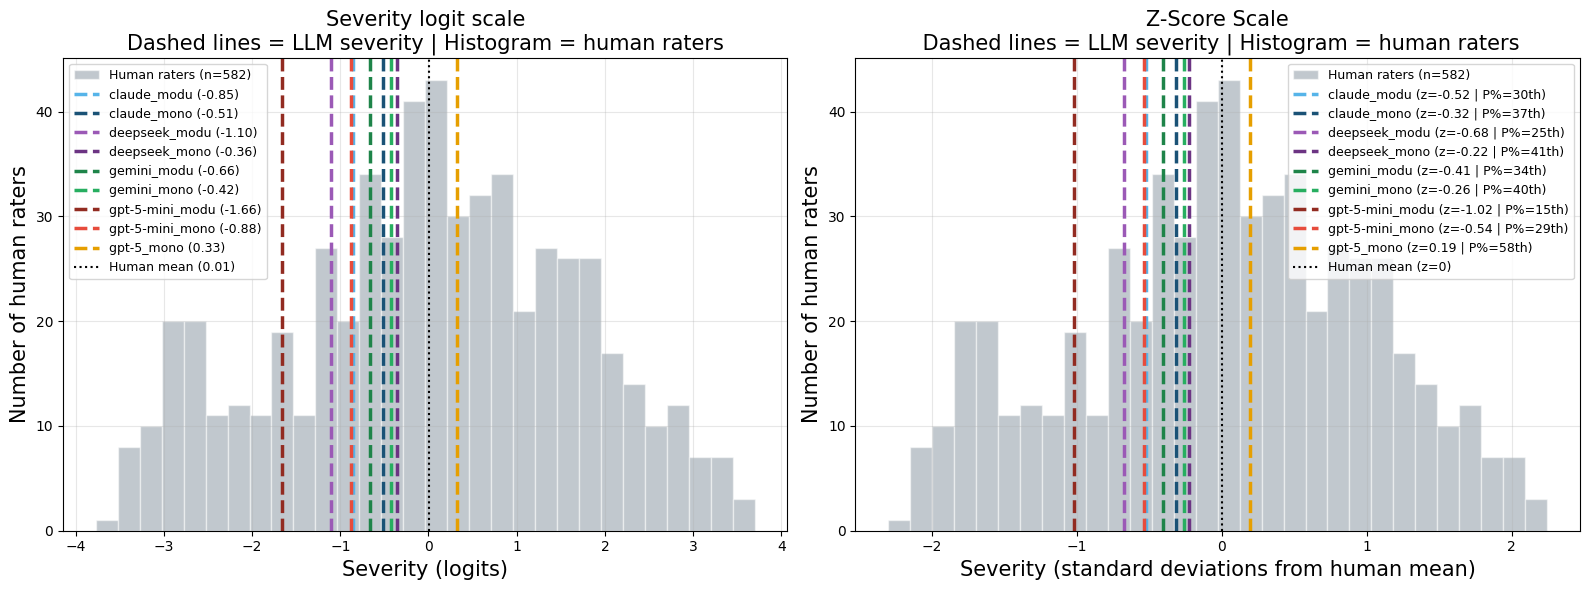

In [34]:
# Run plotting functions
from config import COLORS
# plot_severity_strip(severity_for_plotting, colors=COLORS)
plot_severity_with_context_zscore(severity_for_plotting_2, colors=COLORS)

# Person's ability (theta[n])

The "Persons" in this table represent the specific comments in the dataset. Interpreting other columns:

**Estimate ($\theta_n$)**
This is the central output you are looking for—the **final continuous hate speech score** for each comment. It is calculated on a logit scale.
- Comment with highly positive estimate -->  it was rated as the most severe/hateful comment.
- Comment with highly negative estimate -->  it was rated as the least severe/hateful comment.

## Extract and comparing person ability estimates (theta) 

### Ground_Truth:  what hate score do the individual llm and humans produce

In [136]:
# # =============================================================================
# # EXTRACT ALL THETAS
# # =============================================================================
def extract_theta(mfrm, label=""):
    mfrm.person_stats_df_global()
    theta = mfrm.person_stats_global.get('Estimate')
    theta.index.name = 'comment_id'
    if theta is None or theta.empty:
        raise ValueError(f"No theta estimates found for: {label}")
    return theta
# ── Extract all thetas ────────────────────────────────────────────────────────
thetas_joint =  pd.DataFrame(extract_theta(mfrm_all,           'joint'))


# Merge with Kennedy scores
kennedy_scores = pd_dataframes['gold'][['comment_id', 'hate_speech_score']].set_index('comment_id')
comparison = thetas_joint.reset_index().merge(
    kennedy_scores,
    on='comment_id',
    how='inner'
)
comparison.rename(columns={'hate_speech_score': 'kennedy_theta_score', 'Estimate': 'mfrm_joint_all'}, inplace=True) 

r, p   = stats.pearsonr(comparison['mfrm_joint_all'],
                         comparison['kennedy_theta_score'])
mae    = (comparison['mfrm_joint_all'] - 
          comparison['kennedy_theta_score']).abs().mean()
bias   = (comparison['mfrm_joint_all'] - 
          comparison['kennedy_theta_score']).mean()

print("\n=== Joint θₙ vs Kennedy Gold Standard ===")
print(f"r={r:.3f}  p={p:.6f}  MAE={mae:.3f}  Bias={bias:.3f} size = {len(comparison)}")



=== Joint θₙ vs Kennedy Gold Standard ===
r=0.819  p=0.000000  MAE=0.979  Bias=0.427


In [140]:
print("\n=== Joint θₙ vs Kennedy Gold Standard ===")
print(f"r={r:.3f}  p={p:.6f}  MAE={mae:.3f}  Bias={bias:.3f} size = {len(comparison)}")


=== Joint θₙ vs Kennedy Gold Standard ===
r=0.819  p=0.000000  MAE=0.979  Bias=0.427 size = 605


In [138]:
comparison['mfrm_joint_all']

0      0.950
1      0.765
2      0.765
3      0.765
4      0.765
       ...  
600   -1.586
601   -1.586
602    0.233
603    0.233
604    0.233
Name: mfrm_joint_all, Length: 605, dtype: float64

In [139]:
comparison['kennedy_theta_score']

0      0.80
1      2.64
2      2.64
3      2.64
4      2.64
       ... 
600   -2.58
601   -2.58
602    0.39
603    0.39
604    0.39
Name: kennedy_theta_score, Length: 605, dtype: float64

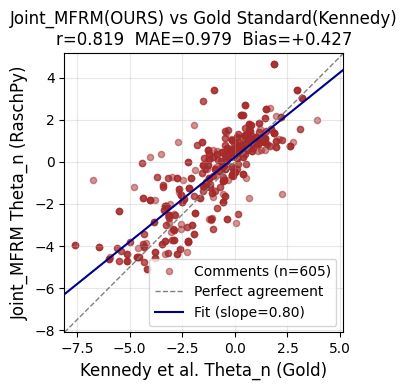

Saved: joint_vs_kennedy_scatter.png


In [137]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, ax = plt.subplots(figsize=(5, 4))

# ── Scatter points ────────────────────────────────────────
ax.scatter(
    comparison['kennedy_theta_score'],
    comparison['mfrm_joint_all'],
    color='brown',
    alpha=0.5,
    s=20,
    label='Comments (n=605)'
)

# ── Perfect agreement line ────────────────────────────────
lims = [
    min(comparison['kennedy_theta_score'].min(),
        comparison['mfrm_joint_all'].min()) - 0.5,
    max(comparison['kennedy_theta_score'].max(),
        comparison['mfrm_joint_all'].max()) + 0.5
]
ax.plot(lims, lims,
        color='gray',
        linestyle='--',
        linewidth=1,
        label='Perfect agreement')

# ── OLS fit line ──────────────────────────────────────────
m, b = np.polyfit(
    comparison['kennedy_theta_score'],
    comparison['mfrm_joint_all'], 1
)
x_fit = np.linspace(lims[0], lims[1], 200)
ax.plot(x_fit, m * x_fit + b,
        color='darkblue',
        linewidth=1.5,
        label=f'Fit (slope={m:.2f})')

# ── Labels and stats ──────────────────────────────────────
ax.set_xlabel('Kennedy et al. Theta_n (Gold)', fontsize=12)
ax.set_ylabel('Joint_MFRM Theta_n (RaschPy)', fontsize=12)
ax.set_title(
    f'Joint_MFRM(OURS) vs Gold Standard(Kennedy)\n'
    f'r={r:.3f}  MAE={mae:.3f}  Bias={bias:+.3f}',
    fontsize=12
)
ax.legend(fontsize=10)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('joint_vs_kennedy_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: joint_vs_kennedy_scatter.png")

In [74]:

# =============================================================================
# EXTRACT ALL THETAS
# =============================================================================
# def extract_theta(mfrm, label=""):
#     mfrm.person_stats_df_global()
#     theta = mfrm.person_stats_global.get('Estimate')
#     if theta is None or theta.empty:
#         raise ValueError(f"No theta estimates found for: {label}")
#     theta.index.name = 'comment_id'
#     return theta
# ── Extract all thetas ────────────────────────────────────────────────────────
thetas = {
    'human'         : extract_theta(mfrm_humans,        'human'),
    'joint'         : extract_theta(mfrm_all,           'joint'),
    'GPT5_mono'     : extract_theta(mfrm_GPT5_mono,     'GPT5_mono'),
    'gpt-5-mini_mono' : extract_theta(mfrm_gpt5mini_mono, 'gpt-5-mini_mono'),
    'gpt-5-mini_modu' : extract_theta(mfrm_gpt5mini_modu, 'gpt-5-mini_modu'),
    'claude_mono'   : extract_theta(mfrm_claude_mono,   'claude_mono'),
    'claude_modu'   : extract_theta(mfrm_claude_modu,   'claude_modu'),
    'gemini_mono'   : extract_theta(mfrm_gemini_mono,   'gemini_mono'),
    'gemini_modu'   : extract_theta(mfrm_gemini_modu,   'gemini_modu'),
    'deepseek_mono' : extract_theta(mfrm_deepseek_mono, 'deepseek_mono'),
    'deepseek_modu' : extract_theta(mfrm_deepseek_modu, 'deepseek_modu')
}

all_theta_df = pd.DataFrame(thetas)
print(f"Shape after alignment: {all_theta_df.shape}")
print(f"Comments in all models: {len(all_theta_df)}")
# print(f"\nFirst 5 rows:")
# print(all_theta_df.head().round(3))


# =============================================================================
# PART 1 — Individual models vs human
# =============================================================================
print("\n" + "="*75)
print("PART 1: INDIVIDUAL MODELS — Each LLM calibrated separately")
print("="*75)

print(f"\n{'Pair':<35} {'r':>6} {'p':>12} {'MAE':>7} {'Bias':>8}")
print("-"*75)

cols = [c for c in all_theta_df.columns if c != 'joint']

for name_a, name_b in combinations(cols, 2):
    theta_a = all_theta_df[name_a]
    theta_b = all_theta_df[name_b]

    r, p  = stats.pearsonr(theta_a, theta_b)
    mae   = (theta_a - theta_b).abs().mean()
    bias  = (theta_b - theta_a).mean()
    pair  = f"{name_a} vs {name_b}"
    print(f"{pair:<35} {r:>6.3f} {p:>12.6f} {mae:>7.3f} {bias:>8.3f}")

# =============================================================================
# PART 2 — Each LLM vs human
# =============================================================================
print("\n" + "="*75)
print("PART 2: JOINT MODEL — All raters calibrated together")
print("Does joint calibration improve agreement with human scores?")
print("="*75)

print(f"\n{'LLM':<16} {'r':>6} {'p':>10} {'MAE':>7} {'Bias':>8}")
print("-"*55)

llm_cols = [c for c in all_theta_df.columns if c not in ('human', 'joint')]

for name in llm_cols:
    theta_a = all_theta_df['human']
    theta_b = all_theta_df[name]

    r, p  = stats.pearsonr(theta_a, theta_b)
    mae   = (theta_a - theta_b).abs().mean()
    bias  = (theta_b - theta_a).mean()
    pair  = f"{name} vs {name_b}"
    print(f"{name:<16} {r:>6.3f} {p:>10.6f} {mae:>7.3f} {bias:>8.3f}")
    # {name:<16} {r:>6.3f} {p:>10.6f} {mae:>7.3f} {bias:>8.3f}")

# =============================================================================
# PART 3 — Joint vs human
# =============================================================================
print(f"\n--- Joint model vs human ---")
a = all_theta_df['human']
b = all_theta_df['joint']

r, p   = stats.pearsonr(a, b)
mae    = (a - b).abs().mean()
bias   = (b - a).mean()
print(f"r={r:.3f}  p={p:.6f}  MAE={mae:.3f}  Bias={bias:.3f}")

# =============================================================================
# PART 4 — Summary statistics
# =============================================================================
print(f"\nSummary statistics:")
print(all_theta_df.describe().round(3).to_string())

Shape after alignment: (250, 11)
Comments in all models: 250

PART 1: INDIVIDUAL MODELS — Each LLM calibrated separately

Pair                                     r            p     MAE     Bias
---------------------------------------------------------------------------
human vs GPT5_mono                   0.753     0.000000   1.140   -0.140
human vs gpt-5-mini_mono             0.710     0.000000   1.242    0.333
human vs gpt-5-mini_modu             0.697     0.000000   1.291    0.282
human vs claude_mono                 0.687     0.000000   1.129    0.551
human vs claude_modu                 0.702     0.000000   1.228    0.743
human vs gemini_mono                 0.748     0.000000   1.377    0.403
human vs gemini_modu                 0.759     0.000000   1.207    0.447
human vs deepseek_mono               0.718     0.000000   1.470    0.373
human vs deepseek_modu               0.736     0.000000   1.014    0.525
GPT5_mono vs gpt-5-mini_mono         0.840     0.000000   0.920    0.473

In [75]:
all_theta_df.head()

,human,joint,GPT5_mono,gpt-5-mini_mono,gpt-5-mini_modu,claude_mono,claude_modu,gemini_mono,gemini_modu,deepseek_mono,deepseek_modu
comment_id,,,,,,,,,,,
170,0.773,0.950,0.086,2.124,1.070,0.224,-0.118,2.102,2.225,1.914,1.648
364,1.712,0.765,1.410,1.602,1.510,1.432,1.668,1.426,1.174,1.914,0.946
401,0.964,0.569,0.086,0.135,-0.122,0.224,-0.118,1.417,1.479,0.505,0.413
423,1.311,0.689,1.194,1.602,2.008,0.750,0.973,1.426,1.361,2.161,1.323
545,2.706,3.424,3.337,3.362,5.069,4.219,4.609,5.269,4.638,5.397,4.221
